In [1]:
#Install requirements
%pip install -r "../requirements.txt"

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Import required libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import scipy
import sys
import glob

from sklearn.naive_bayes import GaussianNB

In [3]:
#Add the src to the path
sys.path.append(os.path.abspath(os.path.join('..')))

In [4]:
#Path for the Data
if not os.path.exists("../data/students_dataset.csv"):
    print("Data Path does not exist. Expected in `../data/students_dataset.csv`")
    exit

data = pd.read_csv(os.path.join("../data/students_dataset.csv"))

In [5]:
#Import the nested cross-validation class
from src.nested_cross_validation_feature_selection import NestedCrossValidation
from src.nested_cross_validation_feature_selection import get_models_statistics
from src.nested_cross_validation_feature_selection import plot_metrics

/root/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
#List the estimators with defaulf hyperparametes, set random_state equal to 42
estimator = [('Gaussian_Naive_Bayes', GaussianNB())]
              
#List the estimator's hyperparameter space
parameter_space = {
    'Gaussian_Naive_Bayes': lambda trial:{
        'var_smoothing' : trial.suggest_float('var_smoothing', 1e-11, 1e-7, log=True)
}
}

In [14]:
#Winner estimator - GNB
#Run hyperparameter tuning and feature selection 
NCV_GNB = NestedCrossValidation(data, estimators=estimator, parameter_space=parameter_space, R=10, n_outer=5, n_inner= 3, seed=42, optimize=True, feature_selection=True)
NCV_GNB.runcv()

Processing: Gaussian_Naive_Bayes


[I 2026-05-11 15:55:07,440] A new study created in memory with name: no-name-f28292dd-a7ea-4b53-a767-30c58510ca5a
[I 2026-05-11 15:55:07,559] Trial 0 finished with value: 0.8175949536735624 and parameters: {'var_smoothing': 3.148911647956852e-10}. Best is trial 0 with value: 0.8175949536735624.
[I 2026-05-11 15:55:07,603] Trial 1 finished with value: 0.8175949536735624 and parameters: {'var_smoothing': 6.351221010640693e-08}. Best is trial 0 with value: 0.8175949536735624.
[I 2026-05-11 15:55:07,643] Trial 2 finished with value: 0.8175949536735624 and parameters: {'var_smoothing': 8.47180141881997e-09}. Best is trial 0 with value: 0.8175949536735624.
[I 2026-05-11 15:55:07,680] Trial 3 finished with value: 0.8175949536735624 and parameters: {'var_smoothing': 2.481040974867806e-09}. Best is trial 0 with value: 0.8175949536735624.
[I 2026-05-11 15:55:07,720] Trial 4 finished with value: 0.8175949536735624 and parameters: {'var_smoothing': 4.2079886696066266e-11}. Best is trial 0 with val

Stability Table saved


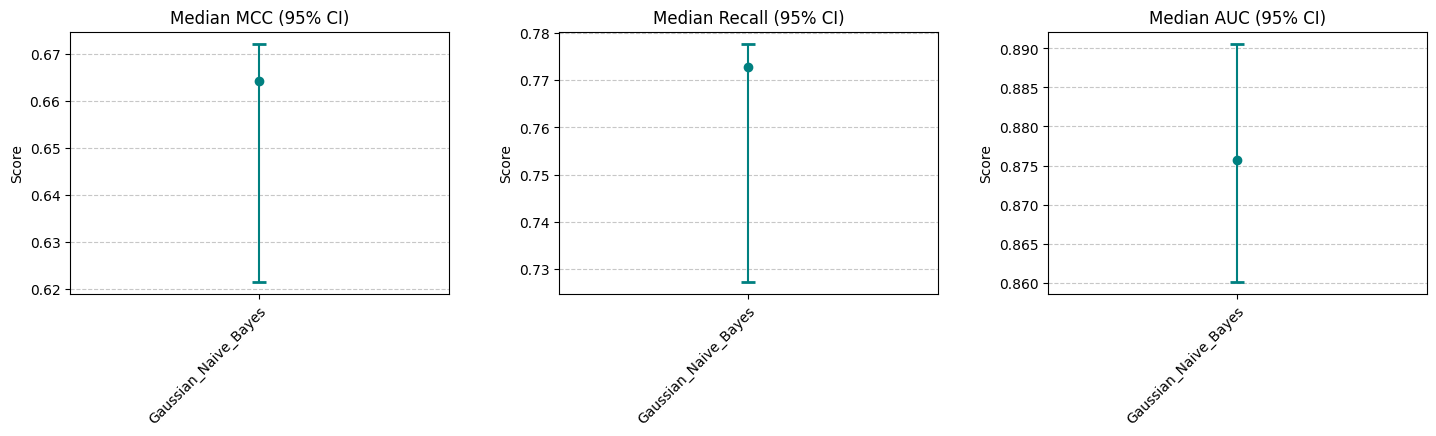

In [15]:
#Get the statistics for each model and plot the selected metrics
baseline_stats = get_models_statistics(NCV_GNB.results, output_filename = "../data/Task4/GNB_feature_selection_report.csv")
plot_metrics(baseline_stats, filename = "../figures/Task4/GNB_feature_selection.png")

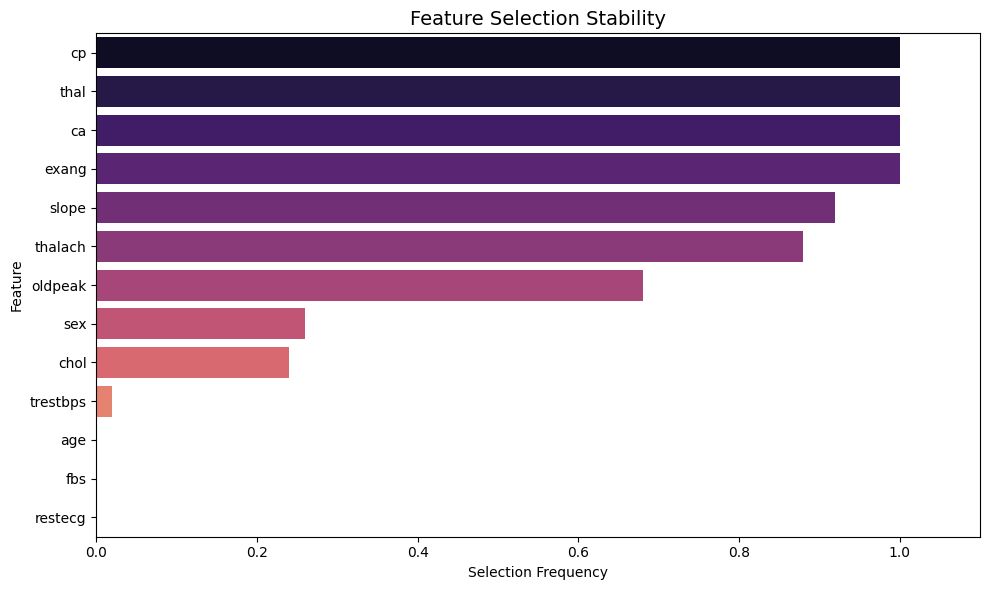

In [17]:
#Load the metrics produced from the hyperparameters tuning in the previous task
stability_data = pd.read_csv("../data/Task4/stability_Gaussian_Naive_Bayes.csv")

#Visualize the frequency of the selected features
plt.figure(figsize=(10,6))
sns.barplot(data=stability_data, x='Frequency', y='Feature', hue='Feature', palette='magma', legend=False)
plt.title("Feature Selection Stability", fontsize=14)
plt.xlabel("Selection Frequency")
plt.xlim(0,1.1)
plt.tight_layout()
plt.savefig("../figures/Task4/gnb_feature_stability.png")
plt.show()

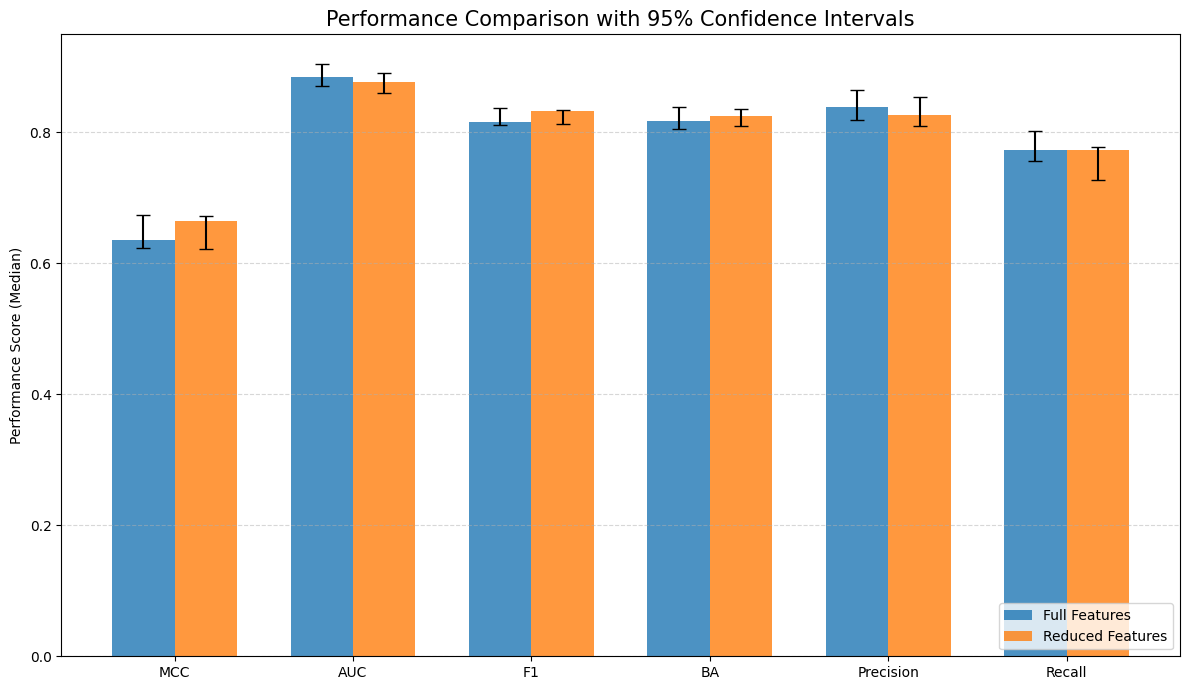

In [10]:
#Compare the tuned GNB model before feature selection with this one after
data_before_feat = pd.read_csv("../data/Task3/tunedboot_results_Gaussian_Naive_Bayes.csv")
data_after_feat = pd.read_csv("../data/Task4/GNB_feature_selection_report.csv")

data_before_feat['Mode'] = 'Full Features'
data_after_feat['Mode'] = 'Reduced Features'

#Concatenate these files
data_combined = pd.concat([data_before_feat, data_after_feat], axis=0)

#Save the final file
data_combined.to_csv("../data/Task4/final_tuned_2models_comparison_table.csv", index=False)

metrics_to_plot = ['MCC', 'AUC', 'F1', 'BA', 'Precision', 'Recall']
plot_df = data_combined[data_combined['Metric'].isin(metrics_to_plot)].copy()

plot_df['err_low'] = plot_df['Median'] - plot_df['CI_Lower']
plot_df['err_high'] = plot_df['CI_Upper'] - plot_df['Median']

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(metrics_to_plot))
width = 0.35

for i, mode in enumerate(plot_df['Mode'].unique()):
    subset = plot_df[plot_df['Mode'] == mode]
    
    subset = subset.set_index('Metric').reindex(metrics_to_plot).reset_index()
    
    #Define error bars
    yerr = [subset['err_low'].values, subset['err_high'].values]
    
    ax.bar(x + (i * width) - (width/2), subset['Median'], width, 
           label=mode, yerr=yerr, capsize=5, alpha=0.8)

ax.set_title("Performance Comparison with 95% Confidence Intervals", fontsize=15)
ax.set_ylabel("Performance Score (Median)")
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("../figures/Task4/model_comparison_with_CI.png")
plt.show()